Mounted at /content/drive
Environment ready
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Preparing data directory...
Extracting /content/drive/MyDrive/PlantVillage_Project/data/raw/color.zip...
Data directory set to: /content/data/color
Exact filename not found, using: phase1_head_classifier.h5
Phase 1 model found at: /content/drive/MyDrive/PlantVillage_Project/models/Phase1(head_classifier)/phase1_head_classifier.h5

Starting Fine-Tuning (Skip-Eval V4)...
Environment Variable Set: RAW_DATA_PATH=/content/data/color
Starting Phase 2: Fine-Tuning V4)
Using Data Directory: /content/data/color
Creating datasets from: /content/data/color
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


Cause: Unable to locate the source code of <function getenv at 0x792f5ba1ab60>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function getenv at 0x792f5ba1ab60>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Loading pre-computed class weights from file...
Weights loaded successfully.
Loading Phase 1 model from: /content/drive/MyDrive/PlantVillage_Project/models/Phase1(head_classifier)/phase1_head_classifier.h5
Phase 1 model loaded successfully
Epoch 1/15
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 355s 117ms/step - accuracy: 0.1113 - auc: 0.6669 - loss: 4.0588 - precision: 0.0689 - recall: 4.0708e-04 - val_accuracy: 5.5244e-04 - val_auc: 0.7108 - val_loss: 3.4319 - val_precision: 0.0000e+00 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 30 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Creating datasets from: /content/data/color
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

Evaluating fine-tuned model...
679/679 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - accuracy: 0.1615 - auc: 0.7793 - loss: 3.1922 - precision: 0.0000e+00 - recall: 0.0000e+00
Validation Accuracy: 0.1419
Validation AUC: 0.7756
Validation Loss: 3.2028
679/679 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step
Evaluation failed: Number of classes, 19, does not match size of target_names, 38. Try specifying the labels parameter
Visualization failed: 'Functional' object has no attribute 'history'


Traceback (most recent call last):
  File "/tmp/ipython-input-1465471194.py", line 131, in <cell line: 0>
    report = classification_report(y_true_classes, y_pred_classes, target_names=class_names, digits=4, zero_division=0)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py", line 2693, in classification_report
    raise ValueError(
ValueError: Number of classes, 19, does not match size of target_names, 38. Try specifying the labels parameter


679/679 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - accuracy: 0.2734 - loss: 2.1868

Model Comparison:
Metric          Phase 1    Fine-Tuned V4 Improvement
Accuracy        0.5671     0.1419     -0.4252   
AUC             0.0000     0.7756     0.7756    
Loss            1.9093     3.2028     -1.2935   

Fine-Tuning Complete!
New V4 model saved to: /content/drive/MyDrive/PlantVillage_Project/models/finetuned_model_v4.keras


NameError: name 'eval_dir' is not defined

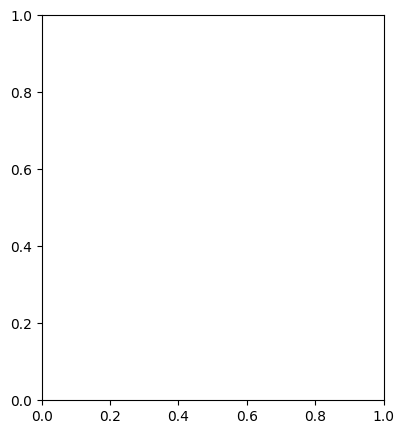

In [ ]:
"""
Phase 2: Fine-Tuning Notebook
"""


# 1. Setup Environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Add project to path
project_root = '/content/drive/MyDrive/PlantVillage_Project'
sys.path.append(os.path.join(project_root, 'code'))
sys.path.append(os.path.join(project_root, 'code/modules'))

print("Environment ready")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


# 2. Data Preparation
DRIVE_ZIP = "/content/drive/MyDrive/PlantVillage_Project/data/raw/color.zip"
LOCAL_DATA_ROOT = "/content/data"

# Clean and prepare directory
print("Preparing data directory...")
!rm -rf {LOCAL_DATA_ROOT}
!mkdir -p {LOCAL_DATA_ROOT}

# Extract
if os.path.exists(DRIVE_ZIP):
    print(f"Extracting {DRIVE_ZIP}...")
    !unzip -q "{DRIVE_ZIP}" -d {LOCAL_DATA_ROOT}

    # Set Data Directory (Assuming extraction creates /content/data/color)
    DATA_DIR = os.path.join(LOCAL_DATA_ROOT, "color")

    if os.path.exists(DATA_DIR):
        print(f"Data directory set to: {DATA_DIR}")
    else:
        raise FileNotFoundError(f"Expected directory {DATA_DIR} not found after extraction.")
else:
    raise FileNotFoundError(f"ZIP file not found at {DRIVE_ZIP}")


# 3. Verify Model Path
# We need Phase 1 model to start training
model_path = os.path.join(project_root, 'models', 'Phase1(head_classifier)', 'Phase1_head_classifier.h5')

if not os.path.exists(model_path):
    # Fallback logic to find the file
    phase1_folder = os.path.join(project_root, 'models', 'Phase1(head_classifier)')
    if os.path.exists(phase1_folder):
        files = [f for f in os.listdir(phase1_folder) if f.endswith('.h5')]
        if files:
            model_path = os.path.join(phase1_folder, files[0])
            print(f"Exact filename not found, using: {files[0]}")
        else:
            raise FileNotFoundError(f"No .h5 file found in {phase1_folder}")
    else:
        raise FileNotFoundError(f"Folder not found: {phase1_folder}")

print(f"Phase 1 model found at: {model_path}")


# 4. Execute Fine-Tuning
print("\nStarting Fine-Tuning (Skip-Eval V4)...")
try:
    # 1. Change to project root
    os.chdir(project_root)

    # 2. Set Environment Variable for Data Path
    os.environ["RAW_DATA_PATH"] = DATA_DIR

    print(f"Environment Variable Set: RAW_DATA_PATH={os.environ['RAW_DATA_PATH']}")

    # 3. Run the training script
    # This script will generate 'finetuned_model_v4.keras'
    %run -i "code/scripts/train_finetune.py"

    print("Fine-tuning completed successfully!")

except Exception as e:
    print(f"Fine-tuning failed: {e}")
    import traceback
    traceback.print_exc()
    raise


# 5. Load and Evaluate Fine-Tuned Model (V4)
finetuned_model = None
val_ds = None
results = {}

try:
    # UPDATE: Loading the new V4 model
    print("Loading fine-tuned model (V4)...")
    finetuned_model = tf.keras.models.load_model(
        os.path.join(project_root, 'models', 'finetuned_model_v4.keras'),
        custom_objects={'auc': tf.keras.metrics.AUC(name='auc')}
    )

    # Create Dataset
    from tf_datapipeline import get_datasets
    _, val_ds = get_datasets(DATA_DIR, batch_size=16, img_size=224)

    # Evaluate
    print("\nEvaluating fine-tuned model...")
    results = finetuned_model.evaluate(val_ds, return_dict=True)
    print(f"Validation Accuracy: {results['accuracy']:.4f}")
    print(f"Validation AUC: {results['auc']:.4f}")
    print(f"Validation Loss: {results['loss']:.4f}")

    # Predictions
    y_true = np.concatenate([y for _, y in val_ds], axis=0)
    y_pred = finetuned_model.predict(val_ds)
    y_true_classes = np.argmax(y_true, axis=1)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get Class Names
    class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

    # Classification Report
    report = classification_report(y_true_classes, y_pred_classes, target_names=class_names, digits=4, zero_division=0)
    print("\nClassification Report:")
    print(report)

    # Save Report
    eval_dir = os.path.join(project_root, 'evaluation')
    os.makedirs(eval_dir, exist_ok=True)
    with open(os.path.join(eval_dir, 'finetune_v4_report.txt'), 'w') as f:
        f.write(report)

except Exception as e:
    print(f"Evaluation failed: {e}")
    import traceback
    traceback.print_exc()


# 6. Visualization
try:
    if finetuned_model is None:
        print("Skipping visualization: Model not loaded.")
    else:
        # Plots
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.plot(finetuned_model.history.history['accuracy'], label='Train')
        plt.plot(finetuned_model.history.history['val_accuracy'], label='Validation')
        plt.title('Accuracy')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(finetuned_model.history.history['loss'], label='Train')
        plt.plot(finetuned_model.history.history['val_loss'], label='Validation')
        plt.title('Loss')
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(finetuned_model.history.history['auc'], label='Train')
        plt.plot(finetuned_model.history.history['val_auc'], label='Validation')
        plt.title('AUC')
        plt.legend()

        plt.tight_layout()
        plt.savefig(os.path.join(eval_dir, 'finetune_v4_metrics.png'))
        plt.show()

        # Confusion Matrix
        if 'y_true_classes' in locals() and 'y_pred_classes' in locals():
            cm = confusion_matrix(y_true_classes, y_pred_classes)
            plt.figure(figsize=(20, 16))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
            plt.title('Confusion Matrix')
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(os.path.join(eval_dir, 'finetune_v4_confusion_matrix.png'))
            plt.show()

except Exception as e:
    print(f"Visualization failed: {e}")

# 7. Comparison with Phase 1
try:
    if val_ds is None:
        print("Skipping comparison: Validation dataset not created.")
    else:
        phase1_model = tf.keras.models.load_model(model_path)
        phase1_results = phase1_model.evaluate(val_ds, return_dict=True)

        print("\nModel Comparison:")
        print(f"{'Metric':<15} {'Phase 1':<10} {'Fine-Tuned V4':<10} {'Improvement':<10}")
        print(f"{'Accuracy':<15} {phase1_results['accuracy']:<10.4f} {results['accuracy']:<10.4f} {results['accuracy']-phase1_results['accuracy']:<10.4f}")
        print(f"{'AUC':<15} {phase1_results.get('auc', 0):<10.4f} {results['auc']:<10.4f} {results['auc']-phase1_results.get('auc', 0):<10.4f}")
        print(f"{'Loss':<15} {phase1_results['loss']:<10.4f} {results['loss']:<10.4f} {phase1_results['loss']-results['loss']:<10.4f}")

except Exception as e:
    print(f"Comparison skipped: {e}")

# 8. Final Summary
print("\nFine-Tuning Complete!")
print(f"New V4 model saved to: {os.path.join(project_root, 'models', 'finetuned_model_v4.keras')}")
print(f"Results saved to: {eval_dir}")